# ST1504 CA2 Part B: Pendulum Control Using Reinforcement Learning

## Objective

The objective of this project is to build and evaluate a Deep Q-Network (DQN) agent capable of balancing a pendulum by applying appropriate torque.

The Pendulum environment provides the agent with three observations:

- Cosine of the pendulum angle
- Sine of the pendulum angle
- Angular velocity of the pendulum

Since the original action space is continuous, the available torque values will be discretised so that DQN can be applied.

The performance of the DQN agent will be investigated under four gravity conditions:

- Default gravity, \(g = 10\)
- Free-fall, \(g = 0\)
- Anti-gravity, \(g = -10\)
- Supergravity, \(g = 15\)

In this project, the DQN agent will be trained, evaluated and systematically improved to determine a suitable setup for balancing the pendulum under the different gravity conditions.

In [1]:
import gym
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from collections import deque
from tensorflow.keras import layers

print("Gym version:", gym.__version__)
print("TensorFlow version:", tf.__version__)

Gym version: 0.17.3
TensorFlow version: 2.10.0


## Environment Setup

Unlike supervised learning tasks, reinforcement learning does not begin with a fixed dataset. Instead, training data is generated through interactions between the agent and its environment.

The OpenAI Gym Pendulum environment is created as the data source for this project. During each interaction, the environment provides the agent with a state. The agent selects an action, receives a reward and observes the resulting next state.

The default gravity setting will first be used to explore the environment and develop the baseline DQN agent.

In [2]:
env = gym.make("Pendulum-v0")

state = env.reset()

print("Environment:", env)
print("Initial state:", state)
print("State shape:", state.shape)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Default gravity:", env.unwrapped.g)

env.close()

Environment: <TimeLimit<PendulumEnv<Pendulum-v0>>>
Initial state: [ 0.9954319  -0.09547422  0.12239664]
State shape: (3,)
Observation space: Box(-8.0, 8.0, (3,), float32)
Action space: Box(-2.0, 2.0, (1,), float32)
Default gravity: 10.0


# Exploratory Data Analysis (EDA)
### Environment Structure

The Pendulum environment represents each state using three numerical observations:

- The cosine of the pendulum angle
- The sine of the pendulum angle
- The angular velocity of the pendulum

The first two observations range from **-1 to 1**, while angular velocity ranges from **-8 to 8**. Each state therefore has a shape of **(3,)**.

The original action consists of one continuous torque value ranging from **-2 to 2**. Since DQN requires discrete actions, this action space will later be discretised during preprocessing.

Each episode has a maximum duration of **200 time steps**.

In [3]:
env = gym.make("Pendulum-v0")

print("Observation shape:", env.observation_space.shape)
print("Observation minimum values:", env.observation_space.low)
print("Observation maximum values:", env.observation_space.high)

print("Action shape:", env.action_space.shape)
print("Action minimum value:", env.action_space.low)
print("Action maximum value:", env.action_space.high)

print("Maximum episode length:", env.spec.max_episode_steps)
print("Gravity:", env.unwrapped.g)

env.close()

Observation shape: (3,)
Observation minimum values: [-1. -1. -8.]
Observation maximum values: [1. 1. 8.]
Action shape: (1,)
Action minimum value: [-2.]
Action maximum value: [2.]
Maximum episode length: 200
Gravity: 10.0


### Collection of Random-Agent Interaction Data

Unlike a traditional dataset, reinforcement learning data is generated when an agent interacts with the environment.

A random agent was used to complete multiple episodes. At each time step, the following information was recorded:

- Current state
- Selected torque
- Reward received
- Total episodic return

This exploratory data will be used to examine the distributions of the observations, actions and rewards before developing the DQN agent.

In [4]:
env = gym.make("Pendulum-v0")
env.seed(42)

number_of_episodes = 50

collected_states = []
collected_actions = []
collected_rewards = []
episode_returns = []

for episode in range(number_of_episodes):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = env.action_space.sample()

        next_state, reward, done, info = env.step(action)

        collected_states.append(state)
        collected_actions.append(action[0])
        collected_rewards.append(reward)

        total_reward += reward
        state = next_state

    episode_returns.append(total_reward)

env.close()

collected_states = np.array(collected_states)
collected_actions = np.array(collected_actions)
collected_rewards = np.array(collected_rewards)
episode_returns = np.array(episode_returns)

print("Collected states:", collected_states.shape)
print("Collected actions:", collected_actions.shape)
print("Collected rewards:", collected_rewards.shape)
print("Episode returns:", episode_returns.shape)

Collected states: (10000, 3)
Collected actions: (10000,)
Collected rewards: (10000,)
Episode returns: (50,)


### Interaction Data Quality

The randomly collected states, actions and rewards were checked for missing and infinite values.

Reinforcement learning environments normally generate valid numerical observations. However, this check is still important because invalid values could cause unstable gradients or prevent the DQN from training correctly.

If no missing or infinite values are found, all collected interactions can be retained for exploratory analysis.

In [5]:
print(
    "Missing state values:",
    np.isnan(collected_states).sum()
)

print(
    "Infinite state values:",
    np.isinf(collected_states).sum()
)

print(
    "Missing action values:",
    np.isnan(collected_actions).sum()
)

print(
    "Infinite action values:",
    np.isinf(collected_actions).sum()
)

print(
    "Missing reward values:",
    np.isnan(collected_rewards).sum()
)

print(
    "Infinite reward values:",
    np.isinf(collected_rewards).sum()
)

Missing state values: 0
Infinite state values: 0
Missing action values: 0
Infinite action values: 0
Missing reward values: 0
Infinite reward values: 0


### Distribution of State Observations

The distributions of the three state observations were examined using histograms.

The cosine and sine observations describe the pendulum’s angular position, while angular velocity describes the speed and direction of its rotation.

This analysis helps identify the ranges and distributions experienced by a random agent. It also indicates whether state normalisation may be useful before DQN training.

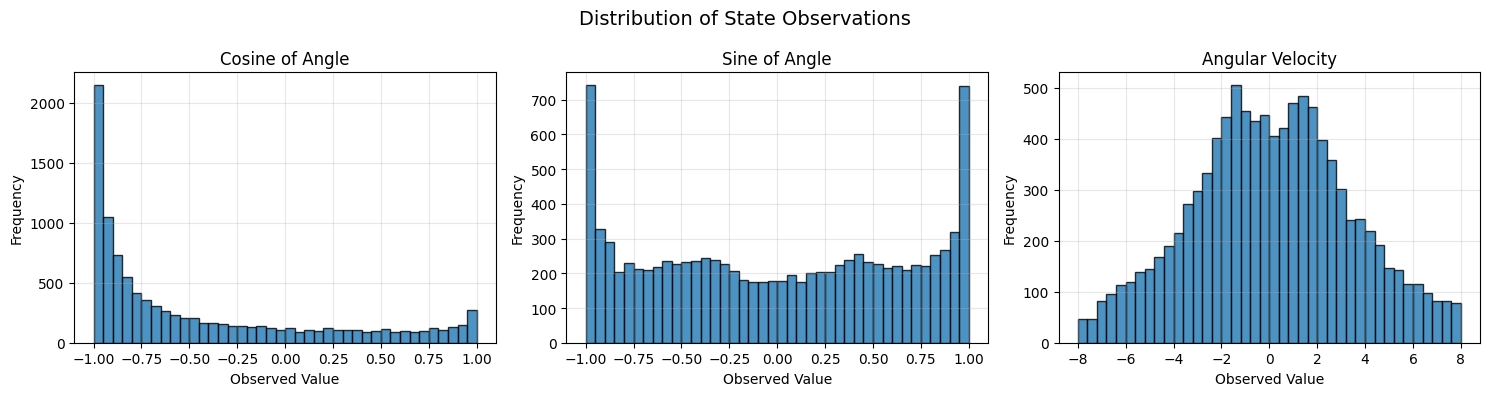

In [6]:
state_names = [
    "Cosine of Angle",
    "Sine of Angle",
    "Angular Velocity"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for index, axis in enumerate(axes):
    axis.hist(
        collected_states[:, index],
        bins=40,
        alpha=0.8,
        edgecolor="black"
    )

    axis.set_title(state_names[index])
    axis.set_xlabel("Observed Value")
    axis.set_ylabel("Frequency")
    axis.grid(alpha=0.3)

plt.suptitle(
    "Distribution of State Observations",
    fontsize=14
)

plt.tight_layout()
plt.show()

#### Interpretation of State Distributions

The cosine observation is strongly concentrated near **-1**. Since a cosine value of -1 represents the pendulum pointing downwards, this shows that the random agent frequently allows the pendulum to remain near its natural hanging position. In comparison, the desired upright position has a cosine value near **1**.

The sine observation covers the complete range from -1 to 1, showing that the pendulum moves through positions on both sides of its rotation.

Angular velocity is approximately centred around zero and ranges from about -8 to 8. Its numerical range is considerably wider than the cosine and sine observations, which are limited to -1 to 1. Therefore, scaling angular velocity may help ensure that it does not have a disproportionately large influence during DQN training.

### Distribution of Random Actions and Rewards

The distributions of the randomly selected torque values and the resulting rewards were examined.

Since the actions were sampled randomly from the continuous action space, torque values across the range of -2 to 2 are expected. The reward distribution provides a baseline indication of the performance achieved without learning.

For the Pendulum environment, rewards are negative. Values closer to zero represent better control of the pendulum.

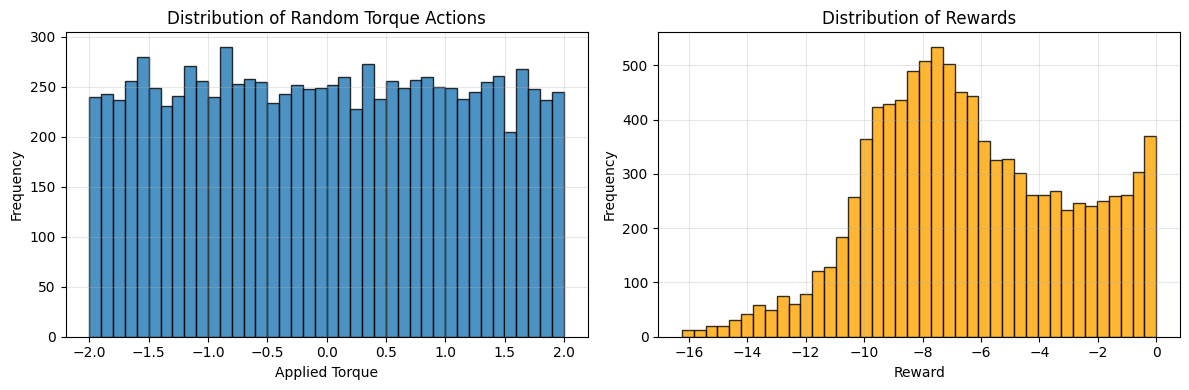

In [7]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].hist(
    collected_actions,
    bins=40,
    edgecolor="black",
    alpha=0.8
)

axes[0].set_title("Distribution of Random Torque Actions")
axes[0].set_xlabel("Applied Torque")
axes[0].set_ylabel("Frequency")
axes[0].grid(alpha=0.3)

axes[1].hist(
    collected_rewards,
    bins=40,
    edgecolor="black",
    alpha=0.8,
    color="orange"
)

axes[1].set_title("Distribution of Rewards")
axes[1].set_xlabel("Reward")
axes[1].set_ylabel("Frequency")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation of Random Actions and Rewards

The random torque actions are distributed approximately evenly across the complete range from **-2 to 2**. This confirms that the random agent does not favour any particular torque value or direction.

The per-step rewards range from approximately **-16 to 0**, with most rewards occurring around -10 to -4. Since the maximum possible reward is zero, the mainly negative distribution indicates that the random agent generally fails to keep the pendulum upright and stable.

A smaller number of rewards appear close to zero, showing that the pendulum occasionally reaches a favourable position by chance. However, the random agent cannot maintain this position consistently because it does not learn from previous interactions.

These results provide a baseline that the trained DQN agent should improve upon by achieving rewards that are more consistently concentrated closer to zero.

### Initial Comparison of Gravity Conditions

The Pendulum environment was explored under the four gravity conditions required by the assignment:

- Default gravity, \(g = 10\)
- Free-fall, \(g = 0\)
- Anti-gravity, \(g = -10\)
- Supergravity, \(g = 15\)

A random agent was evaluated under each condition to examine how gravity affects the environment before DQN training.

The same number of episodes and random seed were used for every gravity condition to make the comparison fair. These results represent untrained baseline performance and will later be compared with the trained DQN agents.

In [8]:
gravity_settings = {
    "Default": 10.0,
    "Free-fall": 0.0,
    "Anti-gravity": -10.0,
    "Supergravity": 15.0
}

episodes_per_gravity = 30
gravity_baseline_returns = {}

for gravity_name, gravity_value in gravity_settings.items():
    env = gym.make("Pendulum-v0")
    env.unwrapped.g = gravity_value

    env.seed(42)
    env.action_space.seed(42)

    condition_returns = []

    for episode in range(episodes_per_gravity):
        state = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = env.action_space.sample()

            next_state, reward, done, info = env.step(action)

            total_reward += reward
            state = next_state

        condition_returns.append(total_reward)

    gravity_baseline_returns[gravity_name] = np.array(
        condition_returns
    )

    env.close()

    print(
        gravity_name,
        "- Mean:",
        np.mean(condition_returns),
        "- Standard deviation:",
        np.std(condition_returns)
    )

Default - Mean: -1346.5742250825601 - Standard deviation: 255.82706038709767
Free-fall - Mean: -755.5639145162427 - Standard deviation: 202.96446035405484
Anti-gravity - Mean: -846.961896779236 - Standard deviation: 470.177447831434
Supergravity - Mean: -1475.540829003154 - Standard deviation: 163.53696966996168


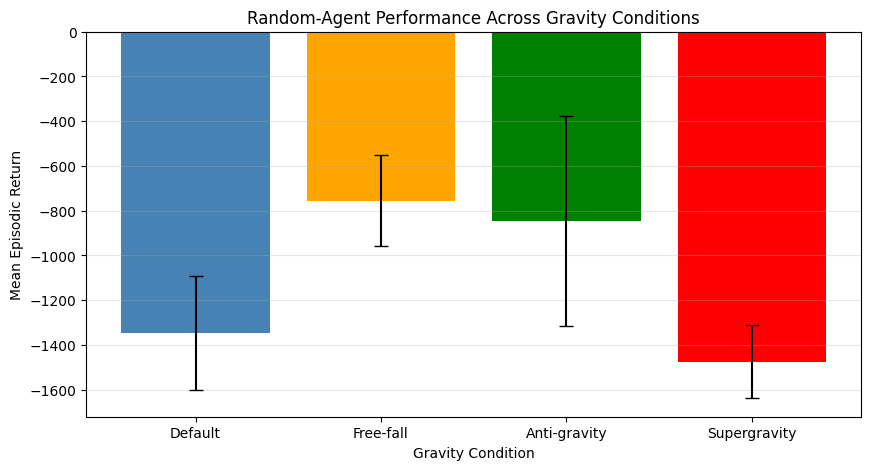

In [9]:
gravity_names = list(gravity_baseline_returns.keys())

mean_returns = [
    gravity_baseline_returns[name].mean()
    for name in gravity_names
]

return_standard_deviations = [
    gravity_baseline_returns[name].std()
    for name in gravity_names
]

plt.figure(figsize=(10, 5))

plt.bar(
    gravity_names,
    mean_returns,
    yerr=return_standard_deviations,
    capsize=5,
    color=["steelblue", "orange", "green", "red"]
)

plt.title("Random-Agent Performance Across Gravity Conditions")
plt.xlabel("Gravity Condition")
plt.ylabel("Mean Episodic Return")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretation of Gravity Baselines

The random agent achieved different levels of performance under the four gravity conditions.

Free-fall produced the highest mean episodic return, with an average of approximately **-760**. Without gravitational force pulling the pendulum downwards, the random agent was more likely to remain in comparatively favourable positions.

Anti-gravity produced the second-highest mean return of approximately **-850**. However, it also had the largest standard deviation, indicating that its performance varied considerably between episodes.

The default-gravity condition produced a lower mean return of approximately **-1350**, while supergravity produced the lowest mean return of approximately **-1480**. The stronger gravitational force in supergravity makes it more difficult for randomly selected torque actions to move and maintain the pendulum near the upright position.

The overlapping error bars show that random-agent performance varies between episodes. Therefore, multiple evaluation episodes should also be used when comparing trained DQN agents.

Each trained agent should be compared against the random baseline from the same gravity condition because the four environments have different levels of difficulty.

## Data Preprocessing

The exploratory analysis found no missing or infinite values in the environment observations, actions or rewards. Therefore, no interaction data needs to be removed or imputed.

However, two preprocessing steps are required before DQN can be applied:

1. Discretise the continuous torque action space.
2. Scale the state observations to a similar numerical range.

These transformations will make the Pendulum environment suitable for training with a Deep Q-Network.

### Action-Space Discretisation

The original Pendulum action space contains continuous torque values ranging from -2 to 2. However, DQN can only select from a fixed number of discrete actions.

For the baseline model, the continuous range is divided into five evenly spaced torque values:

- Strong clockwise torque
- Weak clockwise torque
- No torque
- Weak counter-clockwise torque
- Strong counter-clockwise torque

Five actions provide a simple baseline while still allowing the agent to control both the direction and strength of the applied torque. Different numbers of actions can later be investigated as a systematic improvement.

In [10]:
number_of_actions = 5

torque_values = np.linspace(
    -2.0,
    2.0,
    number_of_actions
).astype("float32")

for action_index, torque in enumerate(torque_values):
    print(
        f"Action {action_index}: "
        f"Torque = {torque:.1f}"
    )

Action 0: Torque = -2.0
Action 1: Torque = -1.0
Action 2: Torque = 0.0
Action 3: Torque = 1.0
Action 4: Torque = 2.0


In [11]:
def action_index_to_torque(action_index):
    torque = torque_values[action_index]

    return np.array(
        [torque],
        dtype=np.float32
    )

In [12]:
test_action_index = 3
test_torque = action_index_to_torque(
    test_action_index
)

print("Selected action index:", test_action_index)
print("Applied torque:", test_torque)

Selected action index: 3
Applied torque: [1.]


### State Casting and Scaling

The state contains three observations with different numerical ranges:

- Cosine of angle: -1 to 1
- Sine of angle: -1 to 1
- Angular velocity: -8 to 8

The cosine and sine observations are already within the range of -1 to 1. However, angular velocity has a much wider range and could have a disproportionately large influence on the neural network.

Therefore, angular velocity is divided by 8 so that all three state features are approximately within the same range of -1 to 1.

The states are also converted to `float32`, which is suitable for TensorFlow model training.

In [13]:
state_scale = np.array(
    [1.0, 1.0, 8.0],
    dtype=np.float32
)


def preprocess_state(state):
    state = np.asarray(
        state,
        dtype=np.float32
    )

    scaled_state = state / state_scale

    return np.clip(
        scaled_state,
        -1.0,
        1.0
    )

In [14]:
env = gym.make("Pendulum-v0")

original_state = env.reset()
processed_state = preprocess_state(
    original_state
)

env.close()

print("Original state:", original_state)
print("Processed state:", processed_state)

print(
    "Processed datatype:",
    processed_state.dtype
)

Original state: [0.57743937 0.81643357 0.19484807]
Processed state: [0.57743937 0.81643355 0.02435601]
Processed datatype: float32


In [15]:
processed_collected_states = np.array([
    preprocess_state(state)
    for state in collected_states
])

print(
    "Original minimum values:",
    collected_states.min(axis=0)
)

print(
    "Original maximum values:",
    collected_states.max(axis=0)
)

print(
    "Processed minimum values:",
    processed_collected_states.min(axis=0)
)

print(
    "Processed maximum values:",
    processed_collected_states.max(axis=0)
)

Original minimum values: [-0.99999995 -0.99999999 -8.        ]
Original maximum values: [0.99999971 1.         8.        ]
Processed minimum values: [-0.99999994 -1.         -1.        ]
Processed maximum values: [0.9999997 1.        1.       ]


### Verification of State Preprocessing

Before preprocessing, the cosine and sine observations were already within the range of -1 to 1, while angular velocity ranged from -8 to 8.

After scaling, all three observations were within approximately -1 to 1. This confirms that angular velocity was successfully scaled without changing the original meaning of the state.

Small differences from the exact limits, such as 0.9999997 instead of 1.0, are caused by floating-point precision and do not require correction.

## Modelling

### 1. Baseline Deep Q-Network

A Deep Q-Network is used to estimate the expected future reward associated with each discrete torque action.

The network receives the three processed state observations as input and produces five Q-values as output, with one Q-value for each available torque action. The action with the highest predicted Q-value represents the action that the agent currently expects to produce the greatest future reward.

The baseline DQN will use experience replay, epsilon-greedy exploration and a separate target network to improve training stability.